In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/quannvh/codebert-gnn-stat/precomputed_features_with_stats.pt
/kaggle/input/datasets/quannvh/codebert-gnn-stat/mismatch_type3_4.csv
/kaggle/input/datasets/quannvh/codebert-gnn-stat/best_model.pth
/kaggle/input/datasets/quannvh/codebert-gnn-stat/__huggingface_repos__.json
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/config.json
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/trainer_state.json
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/training_args.bin
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/scaler.pt
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoint-24535/scheduler.pt
/kaggle/input/datasets/quannvh/datasemantic-clone/checkpoint-24535-20260403T160005Z-3-001/checkpoin

In [1]:
!pip install javalang torch torchvision torchaudio transformers torch-geometric scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70.0 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numb

## Added statistical features for Type-3 / Type-4 mismatch

Bản này bổ sung `stat_vec` cho từng code và `pair_stat` cho từng cặp code. Classifier mới concat thêm thống kê vào vector pair hiện có:

`[h1, h2, |h1-h2|, h1*h2, stat1, stat2, |stat1-stat2|, stat1*stat2, pair_stat]`

Cache feature đổi sang `/kaggle/working/precomputed_features_with_stats.pt` để không load nhầm cache cũ.


In [2]:
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
import json
import numpy as np
import matplotlib.pyplot as plt

import javalang
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch_geometric.nn import GATConv, global_mean_pool
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

@dataclass
class Config:
    codebert_name: str = "microsoft/codebert-base"
    max_code_length: int = 256
    max_ast_nodes: int = 256
    max_dfg_nodes: int = 128
    hidden_dim: int = 256
    num_classes: int = 4
    dropout: float = 0.2
    freeze_codebert: bool = True

cfg = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
@dataclass
class ASTNodeData:
    node_id: int
    node_type: str
    node_name: str = ""
    depth: int = 0
    child_count: int = 0
    flags: Dict[str, int] = field(default_factory=dict)

@dataclass
class ASTEdgeData:
    src: int
    dst: int
    edge_type: str

@dataclass
class ASTGraphSample:
    code: str
    nodes: List[ASTNodeData]
    edges: List[ASTEdgeData]

@dataclass
class DFGNodeData:
    node_id: int
    stmt_type: str
    defs: List[str] = field(default_factory=list)
    uses: List[str] = field(default_factory=list)
    unknown: List[str] = field(default_factory=list)
    text: str = ""

@dataclass
class DFGEdgeData:
    src: int
    dst: int
    edge_type: str

@dataclass
class DFGGraphSample:
    code: str
    nodes: List[DFGNodeData]
    edges: List[DFGEdgeData]

In [4]:
def safe_get_name(node) -> str:
    for attr in ["name", "member", "qualifier", "value"]:
        if hasattr(node, attr):
            val = getattr(node, attr)
            if isinstance(val, str):
                return val
    return ""

def iter_children(node):
    if not isinstance(node, javalang.ast.Node):
        return
    for attr_name in node.attrs:
        value = getattr(node, attr_name)
        if isinstance(value, javalang.ast.Node):
            yield value
        elif isinstance(value, list):
            for item in value:
                if isinstance(item, javalang.ast.Node):
                    yield item

def walk_tree(node):
    if not isinstance(node, javalang.ast.Node):
        return
    yield node
    for child in iter_children(node):
        yield from walk_tree(child)

def parse_java_method(code: str):
    tokens = javalang.tokenizer.tokenize(code)
    parser = javalang.parser.Parser(tokens)
    return parser.parse_member_declaration()

In [5]:
def get_ast_flags(node) -> Dict[str, int]:
    t = type(node).__name__
    return {
        "is_call": int(t == "MethodInvocation"),
        "is_if": int(t == "IfStatement"),
        "is_loop": int(t in {"ForStatement", "WhileStatement", "DoStatement"}),
        "is_try": int(t == "TryStatement"),
        "is_catch": int(t == "CatchClause"),
        "is_return": int(t == "ReturnStatement"),
        "is_assignment": int(t == "Assignment"),
        "is_declaration": int(t in {"LocalVariableDeclaration", "VariableDeclarator", "FormalParameter"}),
    }

def build_ast_graph(code: str, max_nodes: int = 256) -> ASTGraphSample:
    root = parse_java_method(code)
    nodes, edges = [], []

    def dfs(node, depth=0, parent_id=None):
        if len(nodes) >= max_nodes or not isinstance(node, javalang.ast.Node):
            return

        node_id = len(nodes)
        children = list(iter_children(node))

        nodes.append(ASTNodeData(
            node_id=node_id,
            node_type=type(node).__name__,
            node_name=safe_get_name(node),
            depth=depth,
            child_count=len(children),
            flags=get_ast_flags(node),
        ))

        if parent_id is not None:
            edges.append(ASTEdgeData(parent_id, node_id, "PARENT_CHILD"))

        prev_child_id = None
        for child in children:
            if len(nodes) >= max_nodes:
                break
            next_id = len(nodes)
            dfs(child, depth + 1, node_id)
            if next_id < len(nodes):
                if prev_child_id is not None:
                    edges.append(ASTEdgeData(prev_child_id, next_id, "NEXT_SIBLING"))
                prev_child_id = next_id

    dfs(root, 0, None)
    return ASTGraphSample(code=code, nodes=nodes, edges=edges)

In [7]:
print("=====Cell 5 done")

=====Cell 5 done


In [6]:
STATEMENT_TYPES = {
    "LocalVariableDeclaration",
    "StatementExpression",
    "IfStatement",
    "ForStatement",
    "WhileStatement",
    "DoStatement",
    "TryStatement",
    "ReturnStatement",
}

def is_statement_node(node) -> bool:
    return type(node).__name__ in STATEMENT_TYPES

def extract_statements(root):
    return [node for node in walk_tree(root) if is_statement_node(node)]

def extract_identifiers(node) -> List[str]:
    vars_ = []
    for n in walk_tree(node):
        t = type(n).__name__
        if t == "MemberReference":
            if hasattr(n, "member") and isinstance(n.member, str):
                vars_.append(n.member)
        elif t == "FormalParameter":
            if hasattr(n, "name") and isinstance(n.name, str):
                vars_.append(n.name)
        elif t == "VariableDeclarator":
            if hasattr(n, "name") and isinstance(n.name, str):
                vars_.append(n.name)
    return vars_

def dedup_keep_order(xs: List[str]) -> List[str]:
    seen, out = set(), []
    for x in xs:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out

def extract_def_use_from_statement(stmt):
    stmt_type = type(stmt).__name__
    defs, uses, unknown = [], [], []

    if stmt_type == "LocalVariableDeclaration":
        declarators = getattr(stmt, "declarators", []) or []
        for d in declarators:
            if hasattr(d, "name") and d.name:
                defs.append(d.name)
            if hasattr(d, "initializer") and d.initializer is not None:
                uses.extend(extract_identifiers(d.initializer))

    elif stmt_type == "StatementExpression":
        expr = getattr(stmt, "expression", None)
        if expr is not None:
            expr_type = type(expr).__name__
            if expr_type == "Assignment":
                left = getattr(expr, "expressionl", None)
                right = getattr(expr, "value", None)
                if left is not None:
                    defs.extend(extract_identifiers(left))
                if right is not None:
                    uses.extend(extract_identifiers(right))
            else:
                uses.extend(extract_identifiers(expr))

    elif stmt_type == "IfStatement":
        cond = getattr(stmt, "condition", None)
        if cond is not None:
            uses.extend(extract_identifiers(cond))

    elif stmt_type in {"ForStatement", "WhileStatement", "DoStatement", "TryStatement"}:
        uses.extend(extract_identifiers(stmt))

    elif stmt_type == "ReturnStatement":
        expr = getattr(stmt, "expression", None)
        if expr is not None:
            uses.extend(extract_identifiers(expr))
    else:
        uses.extend(extract_identifiers(stmt))

    return (
        dedup_keep_order(defs),
        dedup_keep_order(uses),
        dedup_keep_order(unknown),
    )

def build_dfg_graph(code: str, max_nodes: int = 128) -> DFGGraphSample:
    root = parse_java_method(code)
    statements = extract_statements(root)[:max_nodes]

    nodes, edges = [], []
    stmt_infos = []

    for i, stmt in enumerate(statements):
        defs, uses, unknown = extract_def_use_from_statement(stmt)
        nodes.append(DFGNodeData(
            node_id=i,
            stmt_type=type(stmt).__name__,
            defs=defs,
            uses=uses,
            unknown=unknown,
            text=type(stmt).__name__,
        ))
        stmt_infos.append({"defs": defs, "uses": uses, "unknown": unknown})

    # sequential reaching-def baseline
    for j, info in enumerate(stmt_infos):
        for used_var in info["uses"]:
            for i in range(j - 1, -1, -1):
                if used_var in stmt_infos[i]["defs"]:
                    edges.append(DFGEdgeData(i, j, "DATA_DEP"))
                    break

    return DFGGraphSample(code=code, nodes=nodes, edges=edges)

In [7]:
# ============================================================
# Statistical features for Type-3 / Type-4 improvement
# ============================================================
# Ý tưởng:
# - Mỗi code snippet -> stat_vec: thống kê cấu trúc / API / literal / DFG
# - Mỗi pair -> pair_stat: độ giống nhau API/type/literal/variable + độ lệch feature
# - Classifier sẽ concat thêm [stat1, stat2, |stat1-stat2|, stat1*stat2, pair_stat]

import math
import re
from typing import Set

STAT_KEYS = [
    # size / structure
    "num_ast_nodes",
    "max_ast_depth",
    "num_statements",
    "num_if",
    "num_for",
    "num_while",
    "num_do",
    "num_switch",
    "num_try",
    "num_catch",
    "num_finally",
    "num_return",
    "num_throw",
    "num_assignment",
    "num_binary_op",

    # operation categories
    "file_io_count",
    "stream_io_count",
    "buffer_io_count",
    "zip_io_count",
    "url_network_count",
    "xml_dom_count",
    "string_processing_count",
    "hash_digest_count",
    "collection_count",
    "date_time_count",

    # call / type / literal / variable
    "num_method_invocations",
    "num_unique_api_calls",
    "num_unique_types",
    "num_string_literals",
    "num_numeric_literals",
    "num_variables",

    # DFG summary
    "dfg_num_nodes",
    "dfg_num_edges",
    "dfg_density",
]

PAIR_STAT_KEYS = [
    "api_jaccard",
    "type_jaccard",
    "string_literal_jaccard",
    "variable_jaccard",
    "abs_feature_diff_mean",
    "abs_feature_diff_max",
]

STAT_VECTOR_DIM = len(STAT_KEYS)
PAIR_EXTRA_DIM = len(PAIR_STAT_KEYS)

FILE_IO_HINTS = {
    "File", "Files", "Path", "Paths", "RandomAccessFile", "FileChannel",
    "FileInputStream", "FileOutputStream", "FileReader", "FileWriter",
}
STREAM_IO_HINTS = {
    "InputStream", "OutputStream", "Reader", "Writer", "DataInputStream", "DataOutputStream",
    "ObjectInputStream", "ObjectOutputStream", "ByteArrayInputStream", "ByteArrayOutputStream",
}
BUFFER_IO_HINTS = {"BufferedInputStream", "BufferedOutputStream", "BufferedReader", "BufferedWriter", "ByteBuffer"}
ZIP_IO_HINTS = {"ZipInputStream", "ZipOutputStream", "ZipEntry", "JarInputStream", "JarOutputStream", "GZIPInputStream", "GZIPOutputStream"}
URL_NETWORK_HINTS = {"URL", "URI", "URLConnection", "HttpURLConnection", "Socket", "ServerSocket", "InetAddress"}
XML_DOM_HINTS = {"Document", "Element", "Node", "NodeList", "DocumentBuilder", "SAXParser", "XMLReader"}
COLLECTION_HINTS = {"List", "ArrayList", "Map", "HashMap", "Set", "HashSet", "Collection", "Iterator", "Hashtable", "Vector"}
DATE_TIME_HINTS = {"Date", "Calendar", "LocalDate", "LocalDateTime", "Instant", "SimpleDateFormat", "DateFormat"}
HASH_DIGEST_HINTS = {"MessageDigest", "DigestInputStream", "Mac", "SHA", "MD5", "SHA1", "SHA-1", "SHA256", "SHA-256"}

STRING_METHOD_HINTS = {
    "substring", "indexOf", "lastIndexOf", "startsWith", "endsWith", "contains", "replace",
    "replaceAll", "split", "trim", "toLowerCase", "toUpperCase", "charAt", "append", "toString",
}
FILE_METHOD_HINTS = {
    "exists", "mkdir", "mkdirs", "delete", "renameTo", "createNewFile", "listFiles", "isFile",
    "isDirectory", "getAbsolutePath", "getName", "length", "lastModified", "setLastModified",
}
STREAM_METHOD_HINTS = {"read", "write", "close", "flush", "skip", "available", "reset", "mark"}
HASH_METHOD_HINTS = {"digest", "update", "getInstance"}
COLLECTION_METHOD_HINTS = {"add", "remove", "put", "get", "containsKey", "containsValue", "iterator", "hasNext", "next", "size", "isEmpty"}


def _to_plain_set(xs):
    return {str(x) for x in xs if x is not None and str(x) != ""}


def jaccard(a, b):
    a, b = set(a), set(b)
    if len(a) == 0 and len(b) == 0:
        return 1.0
    union = len(a | b)
    return len(a & b) / union if union > 0 else 0.0


def get_type_name_from_node(node):
    """Lấy type/class name từ các node khai báo hoặc creator trong javalang."""
    for attr in ["type"]:
        if hasattr(node, attr):
            t = getattr(node, attr)
            if hasattr(t, "name") and isinstance(t.name, str):
                return t.name
    if hasattr(node, "name") and type(node).__name__ in {"ClassCreator", "ReferenceType", "BasicType"}:
        return str(node.name)
    return ""


def extract_code_stats(code: str, max_dfg_nodes: int = None):
    """
    Return:
        stat_vec: Tensor [STAT_VECTOR_DIM]
        meta: các set dùng để tạo pair similarity: api_calls, type_names, string_literals, variables
    """
    stats = {k: 0.0 for k in STAT_KEYS}
    meta = {
        "api_calls": set(),
        "type_names": set(),
        "string_literals": set(),
        "numeric_literals": set(),
        "variables": set(),
    }

    try:
        root = parse_java_method(code)
    except Exception:
        return torch.zeros(STAT_VECTOR_DIM, dtype=torch.float), meta

    # AST-level statistics
    for node in walk_tree(root):
        if not isinstance(node, javalang.ast.Node):
            continue

        name = type(node).__name__
        stats["num_ast_nodes"] += 1

        # depth: ưu tiên field depth nếu graph builder đã có, còn không sẽ tính riêng bên dưới
        # Ở đây tính lại max depth bằng DFS bên dưới cho chắc chắn.

        if is_statement_node(node):
            stats["num_statements"] += 1

        if name == "IfStatement": stats["num_if"] += 1
        elif name == "ForStatement": stats["num_for"] += 1
        elif name == "WhileStatement": stats["num_while"] += 1
        elif name == "DoStatement": stats["num_do"] += 1
        elif name == "SwitchStatement": stats["num_switch"] += 1
        elif name == "TryStatement": stats["num_try"] += 1
        elif name == "CatchClause": stats["num_catch"] += 1
        elif name == "ReturnStatement": stats["num_return"] += 1
        elif name == "ThrowStatement": stats["num_throw"] += 1
        elif name == "Assignment": stats["num_assignment"] += 1
        elif name == "BinaryOperation": stats["num_binary_op"] += 1

        # finally không phải lúc nào cũng là node riêng; thường nằm trong TryStatement.finally_block
        if name == "TryStatement" and getattr(node, "finally_block", None):
            stats["num_finally"] += 1

        # method calls / API calls
        if name == "MethodInvocation":
            stats["num_method_invocations"] += 1
            member = getattr(node, "member", "") or ""
            qualifier = getattr(node, "qualifier", "") or ""
            if member:
                meta["api_calls"].add(str(member))
            if qualifier:
                meta["type_names"].add(str(qualifier).split(".")[-1])

            m = str(member)
            q = str(qualifier)
            all_call_text = f"{q}.{m}"
            if m in FILE_METHOD_HINTS or any(h in all_call_text for h in FILE_IO_HINTS):
                stats["file_io_count"] += 1
            if m in STREAM_METHOD_HINTS or any(h in all_call_text for h in STREAM_IO_HINTS):
                stats["stream_io_count"] += 1
            if m in STRING_METHOD_HINTS or "String" in all_call_text or "StringBuilder" in all_call_text:
                stats["string_processing_count"] += 1
            if m in HASH_METHOD_HINTS or any(h in all_call_text for h in HASH_DIGEST_HINTS):
                stats["hash_digest_count"] += 1
            if m in COLLECTION_METHOD_HINTS or any(h in all_call_text for h in COLLECTION_HINTS):
                stats["collection_count"] += 1

        # type/class usage
        tname = get_type_name_from_node(node)
        if tname:
            meta["type_names"].add(tname)

        # variables
        if name == "MemberReference":
            member = getattr(node, "member", "") or ""
            if member:
                meta["variables"].add(str(member))
        elif name in {"VariableDeclarator", "FormalParameter"}:
            v = safe_get_name(node)
            if v:
                meta["variables"].add(v)

        # literals
        if name == "Literal":
            val = str(getattr(node, "value", ""))
            if len(val) >= 2 and (val[0] == '"' or val[0] == "'"):
                meta["string_literals"].add(val.strip('"\''))
            elif re.fullmatch(r"[-+]?\d+(\.\d+)?[a-zA-Z]*", val):
                meta["numeric_literals"].add(val)

    # Max AST depth
    def dfs_depth(n, depth=0):
        if not isinstance(n, javalang.ast.Node):
            return depth
        best = depth
        for ch in iter_children(n):
            best = max(best, dfs_depth(ch, depth + 1))
        return best

    stats["max_ast_depth"] = dfs_depth(root, 0)

    # Category counts based on type names / literals too
    type_names = meta["type_names"]
    lit_text = " ".join(meta["string_literals"])
    if type_names & FILE_IO_HINTS: stats["file_io_count"] += len(type_names & FILE_IO_HINTS)
    if type_names & STREAM_IO_HINTS: stats["stream_io_count"] += len(type_names & STREAM_IO_HINTS)
    if type_names & BUFFER_IO_HINTS: stats["buffer_io_count"] += len(type_names & BUFFER_IO_HINTS)
    if type_names & ZIP_IO_HINTS: stats["zip_io_count"] += len(type_names & ZIP_IO_HINTS)
    if type_names & URL_NETWORK_HINTS: stats["url_network_count"] += len(type_names & URL_NETWORK_HINTS)
    if type_names & XML_DOM_HINTS: stats["xml_dom_count"] += len(type_names & XML_DOM_HINTS)
    if type_names & COLLECTION_HINTS: stats["collection_count"] += len(type_names & COLLECTION_HINTS)
    if type_names & DATE_TIME_HINTS: stats["date_time_count"] += len(type_names & DATE_TIME_HINTS)
    if type_names & HASH_DIGEST_HINTS or any(h.lower() in lit_text.lower() for h in ["md5", "sha", "sha1", "sha-1", "sha256"]):
        stats["hash_digest_count"] += 1
    if any(x in lit_text.lower() for x in ["http://", "https://", "url"]):
        stats["url_network_count"] += 1
    if any(x in lit_text.lower() for x in [".xml", "<xml", "document"]):
        stats["xml_dom_count"] += 1

    stats["num_unique_api_calls"] = len(meta["api_calls"])
    stats["num_unique_types"] = len(meta["type_names"])
    stats["num_string_literals"] = len(meta["string_literals"])
    stats["num_numeric_literals"] = len(meta["numeric_literals"])
    stats["num_variables"] = len(meta["variables"])

    # DFG-level summary
    try:
        dfg = build_dfg_graph(code, max_nodes=max_dfg_nodes or cfg.max_dfg_nodes)
        stats["dfg_num_nodes"] = len(dfg.nodes)
        stats["dfg_num_edges"] = len(dfg.edges)
        n = max(len(dfg.nodes), 1)
        stats["dfg_density"] = len(dfg.edges) / float(n * max(n - 1, 1))
    except Exception:
        pass

    raw = np.array([stats[k] for k in STAT_KEYS], dtype=np.float32)
    # Log scale cho count feature để tránh feature lớn lấn át embedding.
    raw = np.log1p(raw)

    stat_vec = torch.tensor(raw, dtype=torch.float)
    # Chuyển set thành set string thuần để torch.save/load ổn định hơn
    meta = {k: _to_plain_set(v) for k, v in meta.items()}
    return stat_vec, meta


def build_pair_stat_from_meta(feat1: dict, feat2: dict) -> torch.Tensor:
    """Tạo vector similarity/difference cho một pair code."""
    meta1 = feat1.get("stat_meta", {})
    meta2 = feat2.get("stat_meta", {})

    stat1 = feat1["stat_vec"].float()
    stat2 = feat2["stat_vec"].float()
    diff = torch.abs(stat1 - stat2)

    values = [
        jaccard(meta1.get("api_calls", set()), meta2.get("api_calls", set())),
        jaccard(meta1.get("type_names", set()), meta2.get("type_names", set())),
        jaccard(meta1.get("string_literals", set()), meta2.get("string_literals", set())),
        jaccard(meta1.get("variables", set()), meta2.get("variables", set())),
        float(diff.mean().item()),
        float(diff.max().item()),
    ]
    return torch.tensor(values, dtype=torch.float)

print("STAT_VECTOR_DIM =", STAT_VECTOR_DIM)
print("PAIR_EXTRA_DIM  =", PAIR_EXTRA_DIM)


STAT_VECTOR_DIM = 34
PAIR_EXTRA_DIM  = 6


In [8]:
class SimpleVocab:
    def __init__(self):
        self.token2id = {"<UNK>": 0}
        self.id2token = ["<UNK>"]

    def add(self, token: str):
        if token not in self.token2id:
            self.token2id[token] = len(self.id2token)
            self.id2token.append(token)

    def encode(self, token: str) -> int:
        return self.token2id.get(token, 0)

    def __len__(self):
        return len(self.id2token)

ast_type_vocab = SimpleVocab()
dfg_stmt_vocab = SimpleVocab()
var_name_vocab = SimpleVocab()

def build_vocabs(ast_samples, dfg_samples):
    for gs in ast_samples:
        for n in gs.nodes:
            ast_type_vocab.add(n.node_type)
    for gs in dfg_samples:
        for n in gs.nodes:
            dfg_stmt_vocab.add(n.stmt_type)
            for v in n.defs + n.uses + n.unknown:
                var_name_vocab.add(v)

def encode_ast_graph(sample: ASTGraphSample):
    edge_type_map = {"PARENT_CHILD": 0, "NEXT_SIBLING": 1}
    node_type_ids, numeric_feats, edge_index, edge_type_ids = [], [], [], []

    for node in sample.nodes:
        node_type_ids.append(ast_type_vocab.encode(node.node_type))
        numeric_feats.append([
            node.depth,
            node.child_count,
            node.flags["is_call"],
            node.flags["is_if"],
            node.flags["is_loop"],
            node.flags["is_try"],
            node.flags["is_catch"],
            node.flags["is_return"],
            node.flags["is_assignment"],
            node.flags["is_declaration"],
        ])

    for e in sample.edges:
        edge_index.append([e.src, e.dst])
        edge_type_ids.append(edge_type_map[e.edge_type])

    return {
        "node_type_ids": torch.tensor(node_type_ids, dtype=torch.long),
        "numeric_feats": torch.tensor(numeric_feats, dtype=torch.float),
        "edge_index": torch.tensor(edge_index, dtype=torch.long).t().contiguous() if edge_index else torch.zeros((2, 0), dtype=torch.long),
        "edge_type_ids": torch.tensor(edge_type_ids, dtype=torch.long),
    }

def mean_var_id(vars_: List[str]) -> int:
    if not vars_:
        return 0
    ids = [var_name_vocab.encode(v) for v in vars_]
    return int(sum(ids) / len(ids))

def encode_dfg_graph(sample: DFGGraphSample):
    edge_type_map = {"DATA_DEP": 0}
    stmt_type_ids, numeric_feats, edge_index, edge_type_ids = [], [], [], []

    for node in sample.nodes:
        stmt_type_ids.append(dfg_stmt_vocab.encode(node.stmt_type))
        numeric_feats.append([
            len(node.defs),
            len(node.uses),
            len(node.unknown),
            mean_var_id(node.defs),
            mean_var_id(node.uses),
        ])

    for e in sample.edges:
        edge_index.append([e.src, e.dst])
        edge_type_ids.append(edge_type_map[e.edge_type])

    return {
        "stmt_type_ids": torch.tensor(stmt_type_ids, dtype=torch.long),
        "numeric_feats": torch.tensor(numeric_feats, dtype=torch.float),
        "edge_index": torch.tensor(edge_index, dtype=torch.long).t().contiguous() if edge_index else torch.zeros((2, 0), dtype=torch.long),
        "edge_type_ids": torch.tensor(edge_type_ids, dtype=torch.long),
    }

def add_single_batch(graph_dict, key):
    n = graph_dict[key].shape[0]
    graph_dict["batch"] = torch.zeros(n, dtype=torch.long)
    return graph_dict

In [9]:
tokenizer = AutoTokenizer.from_pretrained(cfg.codebert_name)
codebert = AutoModel.from_pretrained(cfg.codebert_name).to(device)

if cfg.freeze_codebert:
    for p in codebert.parameters():
        p.requires_grad = False
    codebert.eval()

def encode_codebert(code: str, max_length: int = 256):
    inputs = tokenizer(
        code,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = codebert(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu()

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [10]:
class ASTEncoder(nn.Module):
    def __init__(self, ast_vocab_size: int, hidden_dim: int):
        super().__init__()
        self.type_emb = nn.Embedding(ast_vocab_size, hidden_dim)
        self.feat_proj = nn.Linear(10, hidden_dim)
        self.gnn1 = GATConv(hidden_dim, hidden_dim, heads=1)
        self.gnn2 = GATConv(hidden_dim, hidden_dim, heads=1)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, node_type_ids, numeric_feats, edge_index, batch):
        x = self.type_emb(node_type_ids) + self.feat_proj(numeric_feats)
        x = F.relu(self.gnn1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.gnn2(x, edge_index))
        return global_mean_pool(x, batch)

class DFGEncoder(nn.Module):
    def __init__(self, stmt_vocab_size: int, hidden_dim: int):
        super().__init__()
        self.type_emb = nn.Embedding(stmt_vocab_size, hidden_dim)
        self.feat_proj = nn.Linear(5, hidden_dim)
        self.gnn1 = GATConv(hidden_dim, hidden_dim, heads=1)
        self.gnn2 = GATConv(hidden_dim, hidden_dim, heads=1)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, stmt_type_ids, numeric_feats, edge_index, batch):
        x = self.type_emb(stmt_type_ids) + self.feat_proj(numeric_feats)
        x = F.relu(self.gnn1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.gnn2(x, edge_index))
        return global_mean_pool(x, batch)

class GatedFusion(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.proj_a = nn.Linear(hidden_dim, hidden_dim)
        self.proj_b = nn.Linear(hidden_dim, hidden_dim)
        self.gate = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, a, b):
        a_ = self.proj_a(a)
        b_ = self.proj_b(b)
        g = torch.sigmoid(self.gate(torch.cat([a_, b_], dim=-1)))
        return g * a_ + (1 - g) * b_

class BaseEncoder(nn.Module):
    def __init__(self, ast_vocab_size, dfg_vocab_size, hidden_dim=256, codebert_dim=768):
        super().__init__()
        self.ast_encoder = ASTEncoder(ast_vocab_size, hidden_dim)
        self.dfg_encoder = DFGEncoder(dfg_vocab_size, hidden_dim)
        self.code_proj = nn.Linear(codebert_dim, hidden_dim)
        self.struct_fusion = GatedFusion(hidden_dim)
        self.final_fusion = GatedFusion(hidden_dim)

    def forward(self, code_vec, ast_graph, dfg_graph):
        h_code = self.code_proj(code_vec)
        h_ast = self.ast_encoder(
            ast_graph["node_type_ids"], ast_graph["numeric_feats"], ast_graph["edge_index"], ast_graph["batch"]
        )
        h_dfg = self.dfg_encoder(
            dfg_graph["stmt_type_ids"], dfg_graph["numeric_feats"], dfg_graph["edge_index"], dfg_graph["batch"]
        )
        h_struct = self.struct_fusion(h_ast, h_dfg)
        return self.final_fusion(h_code, h_struct)

class PairCloneClassifier(nn.Module):
    def __init__(
        self,
        ast_vocab_size,
        dfg_vocab_size,
        hidden_dim=256,
        num_classes=4,
        codebert_dim=768,
        stat_dim=STAT_VECTOR_DIM,
        pair_extra_dim=PAIR_EXTRA_DIM,
    ):
        super().__init__()
        self.base = BaseEncoder(ast_vocab_size, dfg_vocab_size, hidden_dim, codebert_dim)
        self.stat_dim = stat_dim
        self.pair_extra_dim = pair_extra_dim

        base_pair_dim = hidden_dim * 4
        stat_pair_dim = stat_dim * 4
        total_dim = base_pair_dim + stat_pair_dim + pair_extra_dim

        self.cls = nn.Sequential(
            nn.Linear(total_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, feat1, feat2, return_embedding=False):
        h1 = self.base(feat1["code_vec"], feat1["ast_graph"], feat1["dfg_graph"])
        h2 = self.base(feat2["code_vec"], feat2["ast_graph"], feat2["dfg_graph"])

        stat1 = feat1["stat_vec"]
        stat2 = feat2["stat_vec"]
        pair_extra = feat1.get("pair_stat", None)
        if pair_extra is None:
            # Fallback để tránh crash khi debug thủ công.
            pair_extra = torch.zeros((stat1.size(0), self.pair_extra_dim), device=stat1.device, dtype=stat1.dtype)

        z_base = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        z_stat = torch.cat([stat1, stat2, torch.abs(stat1 - stat2), stat1 * stat2], dim=-1)
        z = torch.cat([z_base, z_stat, pair_extra], dim=-1)

        logits = self.cls(z)

        if return_embedding:
            return logits, z

        return logits
        # return self.cls(z)


In [11]:
def load_idx_to_code(jsonl_path: str) -> Dict[str, str]:
    idx_to_code = {}
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            idx_to_code[str(obj["idx"])] = obj["func"]
    return idx_to_code

def load_pairs_txt(txt_path: str) -> List[Tuple[str, str, int]]:
    pairs = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t") if "\t" in line else line.split()
            if len(parts) != 3:
                continue
            idx1, idx2, label = parts
            pairs.append((str(idx1), str(idx2), int(label)))
    return pairs

jsonl_path = "/kaggle/input/datasets/quannvh/datasemantic-clone/dataset (2)/dataset/Multiclass/data.jsonl"
train_path = "/kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/train_50000.txt"
test_path = "/kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/test_50000.txt"
valid_path  = "/kaggle/input/datasets/quannvh/datasemantic-clone/50000-20260403T163943Z-3-001/50000/valid_50000.txt"

idx_to_code = load_idx_to_code(jsonl_path)
train_pairs = load_pairs_txt(train_path)
valid_pairs = load_pairs_txt(valid_path)
test_pairs  = load_pairs_txt(test_path)

print(len(idx_to_code), len(train_pairs), len(valid_pairs), len(test_pairs))

9126 30000 10000 10000


In [12]:
def build_vocabs_from_pairs(pairs, idx_to_code, limit=None):
    ast_samples, dfg_samples = [], []
    iterable = pairs if limit is None else pairs[:limit]

    for idx1, idx2, _ in iterable:
        if idx1 not in idx_to_code or idx2 not in idx_to_code:
            continue
        for idx in [idx1, idx2]:
            code = idx_to_code[idx]
            try:
                ast_samples.append(build_ast_graph(code, max_nodes=cfg.max_ast_nodes))
                dfg_samples.append(build_dfg_graph(code, max_nodes=cfg.max_dfg_nodes))
            except Exception:
                pass

    build_vocabs(ast_samples, dfg_samples)

build_vocabs_from_pairs(train_pairs, idx_to_code, limit=1000)
print(len(ast_type_vocab), len(dfg_stmt_vocab), len(var_name_vocab))

50 9 2579


In [13]:
def prepare_one_code_sample(code: str) -> dict:
    # 1. CodeBERT vector
    code_vec = encode_codebert(code, max_length=cfg.max_code_length)  # shape: (1, 768)

    # 2. AST graph
    ast_sample = build_ast_graph(code, max_nodes=cfg.max_ast_nodes)
    ast_graph = encode_ast_graph(ast_sample)
    ast_graph["batch"] = torch.zeros(ast_graph["node_type_ids"].shape[0], dtype=torch.long)

    # 3. DFG graph
    dfg_sample = build_dfg_graph(code, max_nodes=cfg.max_dfg_nodes)
    dfg_graph = encode_dfg_graph(dfg_sample)
    dfg_graph["batch"] = torch.zeros(dfg_graph["stmt_type_ids"].shape[0], dtype=torch.long)

    # 4. Statistical vector + meta sets for pair similarity
    stat_vec, stat_meta = extract_code_stats(code, max_dfg_nodes=cfg.max_dfg_nodes)

    return {
        "code_vec": code_vec,   # Tensor (1, 768)
        "ast_graph": ast_graph,
        "dfg_graph": dfg_graph,
        "stat_vec": stat_vec,   # Tensor (STAT_VECTOR_DIM,)
        "stat_meta": stat_meta, # dict of sets: api_calls/type_names/string_literals/variables
    }


In [14]:
import os

# Đổi tên cache để tránh load nhầm file cũ chưa có stat_vec/stat_meta.
# feature_path = "/kaggle/working/precomputed_features_with_stats.pt"
feature_path = "/kaggle/input/datasets/quannvh/codebert-gnn-stat/precomputed_features_with_stats.pt"

def cache_has_stat_features(path):
    if not os.path.exists(path):
        return False
    try:
        tmp = torch.load(path, map_location="cpu")
        if not isinstance(tmp, dict) or len(tmp) == 0:
            return False
        first_key = next(iter(tmp.keys()))
        first_feat = tmp[first_key]
        return "stat_vec" in first_feat and "stat_meta" in first_feat
    except Exception:
        return False

if not cache_has_stat_features(feature_path):
    print("Đang tính feature + statistical vector....")
    precomputed_features = {}
    
    # Gom tất cả các ID code thực sự được dùng để tránh tính thừa
    used_indices = set()
    for splits in [train_pairs, valid_pairs, test_pairs]:
        for idx1, idx2, _ in splits:
            used_indices.add(idx1)
            used_indices.add(idx2)

    count = 0
    skipped = 0
    total = len(used_indices)
    
    for idx in used_indices:
        if idx in idx_to_code:
            try:
                precomputed_features[idx] = prepare_one_code_sample(idx_to_code[idx])
            except Exception as e:
                skipped += 1
                # Bỏ qua các code bị lỗi cú pháp/parse graph.
                pass
        
        count += 1
        if count % 500 == 0:
            print(f"Đã xử lý {count}/{total} code snippets... skipped={skipped}")

    torch.save(precomputed_features, feature_path)
    print(f"Xong! Đã lưu {feature_path}")
    print(f"Tổng feature: {len(precomputed_features)}, skipped={skipped}")
else:
    print("Đã tìm thấy cache feature có statistical vector, load vào RAM thôi!")
    
precomputed_features = torch.load(feature_path, map_location="cpu")
print(f"Đã load {len(precomputed_features)} features vào RAM sẵn sàng train.")

# Kiểm tra nhanh một sample
if len(precomputed_features) > 0:
    sample_key = next(iter(precomputed_features.keys()))
    print("Sample keys:", precomputed_features[sample_key].keys())
    print("stat_vec shape:", precomputed_features[sample_key]["stat_vec"].shape)


Đã tìm thấy cache feature có statistical vector, load vào RAM thôi!
Đã load 5886 features vào RAM sẵn sàng train.
Sample keys: dict_keys(['code_vec', 'ast_graph', 'dfg_graph', 'stat_vec', 'stat_meta'])
stat_vec shape: torch.Size([34])


In [15]:
def batch_graphs(graph_list, node_key="node_type_ids"):
    node_ids, numeric_feats, edge_index, edge_type_ids, batch_vec = [], [], [], [], []
    node_offset = 0
    
    for i, g in enumerate(graph_list):
        num_nodes = g[node_key].shape[0]
        if num_nodes == 0:
            continue
            
        node_ids.append(g[node_key])
        numeric_feats.append(g["numeric_feats"])
        
        if g["edge_index"].shape[1] > 0:
            edge_index.append(g["edge_index"] + node_offset)
            edge_type_ids.append(g["edge_type_ids"])
            
        batch_vec.append(torch.full((num_nodes,), i, dtype=torch.long))
        node_offset += num_nodes

    return {
        node_key: torch.cat(node_ids, dim=0) if node_ids else torch.tensor([], dtype=torch.long),
        "numeric_feats": torch.cat(numeric_feats, dim=0) if numeric_feats else torch.tensor([], dtype=torch.float),
        "edge_index": torch.cat(edge_index, dim=1) if edge_index else torch.zeros((2, 0), dtype=torch.long),
        "edge_type_ids": torch.cat(edge_type_ids, dim=0) if edge_type_ids else torch.tensor([], dtype=torch.long),
        "batch": torch.cat(batch_vec, dim=0) if batch_vec else torch.tensor([], dtype=torch.long)
    }

class ClonePairDatasetOptimized(Dataset):
    def __init__(self, pairs, precomputed_features):
        self.samples = []
        for idx1, idx2, label in pairs:
            if idx1 in precomputed_features and idx2 in precomputed_features:
                feat1, feat2 = precomputed_features[idx1], precomputed_features[idx2]
                if feat1["ast_graph"]["node_type_ids"].numel() == 0 or feat1["dfg_graph"]["stmt_type_ids"].numel() == 0 or \
                   feat2["ast_graph"]["node_type_ids"].numel() == 0 or feat2["dfg_graph"]["stmt_type_ids"].numel() == 0:
                    continue
                if "stat_vec" not in feat1 or "stat_vec" not in feat2:
                    continue
                self.samples.append((idx1, idx2, label))
        self.features = precomputed_features

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        idx1, idx2, label = self.samples[i]
        return {
            "idx1": idx1,
            "idx2": idx2,
            "feat1": self.features[idx1],
            "feat2": self.features[idx2],
            "label": label
        }

def pair_collate_fn_truely_batched(batch):
    if len(batch) == 0:
        return None
    
    feat1_ast = batch_graphs([item["feat1"]["ast_graph"] for item in batch], node_key="node_type_ids")
    feat1_dfg = batch_graphs([item["feat1"]["dfg_graph"] for item in batch], node_key="stmt_type_ids")
    feat1_code = torch.cat([item["feat1"]["code_vec"] for item in batch], dim=0)
    feat1_stat = torch.stack([item["feat1"]["stat_vec"] for item in batch], dim=0)

    feat2_ast = batch_graphs([item["feat2"]["ast_graph"] for item in batch], node_key="node_type_ids")
    feat2_dfg = batch_graphs([item["feat2"]["dfg_graph"] for item in batch], node_key="stmt_type_ids")
    feat2_code = torch.cat([item["feat2"]["code_vec"] for item in batch], dim=0)
    feat2_stat = torch.stack([item["feat2"]["stat_vec"] for item in batch], dim=0)

    # Pair-level similarity/difference features được tạo ngay tại collate vì cần cả feat1 và feat2.
    pair_stat = torch.stack([
        build_pair_stat_from_meta(item["feat1"], item["feat2"])
        for item in batch
    ], dim=0)

    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    idx1_list = [item["idx1"] for item in batch]
    idx2_list = [item["idx2"] for item in batch]
    
    return {
        "idx1": idx1_list,
        "idx2": idx2_list,
        "feat1": {
            "ast_graph": feat1_ast,
            "dfg_graph": feat1_dfg,
            "code_vec": feat1_code,
            "stat_vec": feat1_stat,
            "pair_stat": pair_stat,  # gắn vào feat1 để giữ forward(model(feat1, feat2))
        },
        "feat2": {
            "ast_graph": feat2_ast,
            "dfg_graph": feat2_dfg,
            "code_vec": feat2_code,
            "stat_vec": feat2_stat,
        },
        "label": labels
    }

train_dataset = ClonePairDatasetOptimized(train_pairs, precomputed_features)
valid_dataset = ClonePairDatasetOptimized(valid_pairs, precomputed_features)
test_dataset  = ClonePairDatasetOptimized(test_pairs, precomputed_features)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=pair_collate_fn_truely_batched, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=pair_collate_fn_truely_batched, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=pair_collate_fn_truely_batched, num_workers=4)


In [16]:
print(len(train_loader))
print(len(valid_loader))
print(len(test_loader))

1227
409
406


In [17]:
pair_model = PairCloneClassifier(
    ast_vocab_size=len(ast_type_vocab),
    dfg_vocab_size=len(dfg_stmt_vocab),
    hidden_dim=cfg.hidden_dim,
    num_classes=cfg.num_classes,
    stat_dim=STAT_VECTOR_DIM,
    pair_extra_dim=PAIR_EXTRA_DIM,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [p for p in pair_model.parameters() if p.requires_grad],
    lr=1e-4
)

print(pair_model)


PairCloneClassifier(
  (base): BaseEncoder(
    (ast_encoder): ASTEncoder(
      (type_emb): Embedding(50, 256)
      (feat_proj): Linear(in_features=10, out_features=256, bias=True)
      (gnn1): GATConv(256, 256, heads=1)
      (gnn2): GATConv(256, 256, heads=1)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (dfg_encoder): DFGEncoder(
      (type_emb): Embedding(9, 256)
      (feat_proj): Linear(in_features=5, out_features=256, bias=True)
      (gnn1): GATConv(256, 256, heads=1)
      (gnn2): GATConv(256, 256, heads=1)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (code_proj): Linear(in_features=768, out_features=256, bias=True)
    (struct_fusion): GatedFusion(
      (proj_a): Linear(in_features=256, out_features=256, bias=True)
      (proj_b): Linear(in_features=256, out_features=256, bias=True)
      (gate): Linear(in_features=512, out_features=256, bias=True)
    )
    (final_fusion): GatedFusion(
      (proj_a): Linear(in_features=256, out_features=256, bias

In [19]:
def move_feat_to_device(sample_feat, device):
    out = {
        "code_vec": sample_feat["code_vec"].to(device),
        "stat_vec": sample_feat["stat_vec"].to(device),
        "ast_graph": {k: v.to(device) for k, v in sample_feat["ast_graph"].items()},
        "dfg_graph": {k: v.to(device) for k, v in sample_feat["dfg_graph"].items()},
    }
    if "pair_stat" in sample_feat:
        out["pair_stat"] = sample_feat["pair_stat"].to(device)
    return out

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_count = 0.0, 0

    for batch in loader:
        if batch is None:
            continue

        optimizer.zero_grad()
        
        feat1 = move_feat_to_device(batch["feat1"], device)
        feat2 = move_feat_to_device(batch["feat2"], device)
        label = batch["label"].to(device)

        logits = model(feat1, feat2)
        loss = criterion(logits, label)
        loss.backward()
        optimizer.step()

        batch_size = label.size(0)
        total_loss += float(loss.item()) * batch_size
        total_count += batch_size

    return total_loss / max(total_count, 1)

def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_count = 0.0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue

            feat1 = move_feat_to_device(batch["feat1"], device)
            feat2 = move_feat_to_device(batch["feat2"], device)
            label = batch["label"].to(device)

            logits = model(feat1, feat2)
            loss = criterion(logits, label)

            batch_size = label.size(0)
            total_loss += float(loss.item()) * batch_size
            total_count += batch_size

            pred = torch.argmax(logits, dim=-1)
            y_true.extend(label.cpu().tolist())
            y_pred.extend(pred.cpu().tolist())

    accuracy = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    return {
        "loss": total_loss / max(total_count, 1),
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_per_class": precision_per_class,
        "recall_per_class": recall_per_class,
        "f1_per_class": f1_per_class,
        "support_per_class": support_per_class,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
    }


In [20]:
def print_metrics(metrics, class_names=None):
    class_names = class_names or ["Type-1", "Type-2", "Type-3", "Type-4"]
    print(f"loss            : {metrics['loss']:.4f}")
    print(f"accuracy        : {metrics['accuracy']:.4f}")
    print(f"precision_macro : {metrics['precision_macro']:.4f}")
    print(f"recall_macro    : {metrics['recall_macro']:.4f}")
    print(f"f1_macro        : {metrics['f1_macro']:.4f}")
    print()
    for i, name in enumerate(class_names):
        print(
            f"{name:7s} | "
            f"P={metrics['precision_per_class'][i]:.4f}  "
            f"R={metrics['recall_per_class'][i]:.4f}  "
            f"F1={metrics['f1_per_class'][i]:.4f}  "
            f"Support={metrics['support_per_class'][i]}"
        )

def plot_confusion_matrix_percent(metrics, class_names=None, figsize=(7, 7)):
    class_names = class_names or ["Type-1", "Type-2", "Type-3", "Type-4"]
    cm = metrics["confusion_matrix"].astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    cm_percent = cm / row_sums * 100.0

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_percent, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        title='Confusion Matrix (%)',
        ylabel='True label',
        xlabel='Predicted label'
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm_percent.max() / 2.0
    for i in range(cm_percent.shape[0]):
        for j in range(cm_percent.shape[1]):
            ax.text(
                j, i, f"{cm_percent[i, j]:.2f}%",
                ha="center", va="center",
                color="white" if cm_percent[i, j] > thresh else "black"
            )

    fig.tight_layout()
    plt.show()

In [22]:
print(device)
print(next(pair_model.parameters()).device)

cuda
cuda:0


In [23]:
# import time 

# start_time = time.time()
# best_f1 = -1.0
# best_state = None
# num_epochs = 30

# for epoch in range(num_epochs):
#     epoch_start_time = time.time()
#     train_loss = train_one_epoch(pair_model, train_loader, optimizer, criterion, device)
#     valid_metrics = eval_one_epoch(pair_model, valid_loader, criterion, device)

#     epoch_time = time.time() - epoch_start_time
#     print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")
#     print(f"train_loss: {train_loss:.4f}")
#     print_metrics(valid_metrics)

#     print(f"\nTime training epoch: {epoch_time} seconds")
#     if valid_metrics["f1_macro"] > best_f1:
#         best_f1 = valid_metrics["f1_macro"]
#         best_state = {k: v.cpu() for k, v in pair_model.state_dict().items()}
#         torch.save(best_state,"/kaggle/working/best_model.pth")
#         print("Save model successedfully")
#         print(f"New best macro F1: {best_f1:.4f}")
# total_training_time = time.time() - start_time
# print(f"Time trainning for all epochs: {total_training_time} seconds")
# hours = int(total_training_time // 3600)
# minutes = int((total_training_time % 3600) // 60)
# seconds = int(total_training_time % 60)

# print("\n===== TRAINING FINISHED =====")
# print(f"Total training time: {hours}h {minutes}m {seconds}s")
    

In [24]:
test = 159393436
demo = 939483
print(test/demo)

169.66079854558305


✅ Đã load trọng số hội tụ tốt nhất!

⏳ Đang chạy đánh giá trên tập Test...

📊 KẾT QUẢ TẬP TEST:
--------------------------------------------------
loss            : 0.1033
accuracy        : 0.9570
precision_macro : 0.9582
recall_macro    : 0.9598
f1_macro        : 0.9589

Type-1  | P=0.9878  R=1.0000  F1=0.9939  Support=812
Type-2  | P=0.9978  R=0.9955  F1=0.9966  Support=2234
Type-3  | P=0.9165  R=0.9307  F1=0.9235  Support=1745
Type-4  | P=0.9306  R=0.9131  F1=0.9218  Support=1703

🎨 Đang vẽ Confusion Matrix...


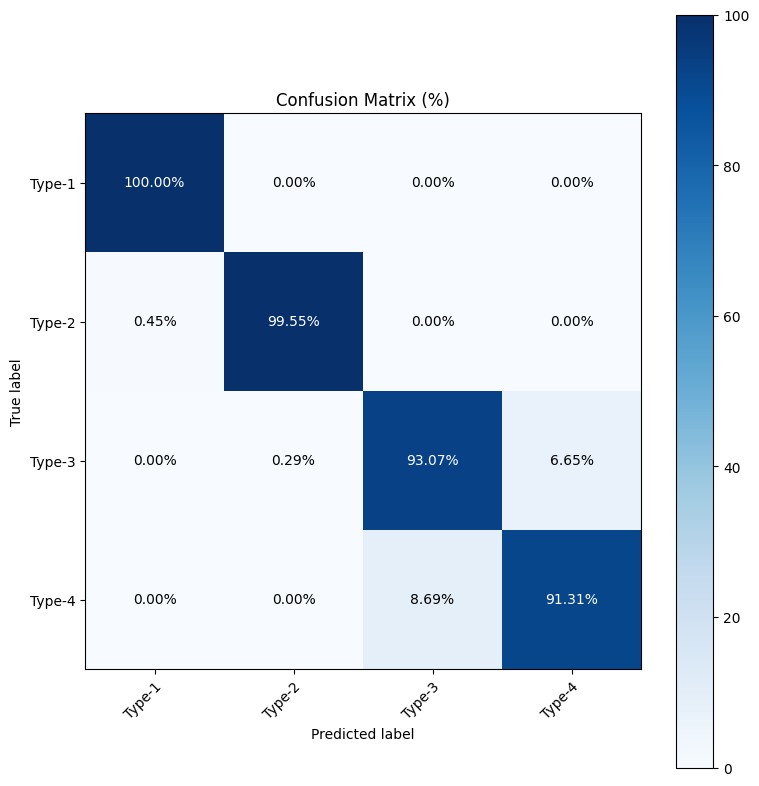

In [39]:
# === Cell 17: Load Best Model & Vẽ Confusion Matrix ===
best_state = torch.load("/kaggle/input/datasets/quannvh/codebert-gnn-stat/best_model.pth")
if best_state is not None:
    pair_model.load_state_dict(best_state)
    print("✅ Đã load trọng số hội tụ tốt nhất!")

# Đảm bảo model vẫn ở trên GPU để chạy cho nhanh
pair_model.to(device)

print("\n⏳ Đang chạy đánh giá trên tập Test...")
# start_time = time.time()
test_metrics = eval_one_epoch(pair_model, test_loader, criterion, device)
# total_time = time.time() - start_time//
# print(f"Total time for testing: {total_time}")
nums_sample = len(test_loader.dataset)
# print(f"Avg time for valid test for each sample: {total_time/nums_sample} seconds")

print("\n📊 KẾT QUẢ TẬP TEST:")
print("-" * 50)
print_metrics(test_metrics, class_names=["Type-1", "Type-2", "Type-3", "Type-4"])

print("\n🎨 Đang vẽ Confusion Matrix...")
plot_confusion_matrix_percent(
    test_metrics, 
    class_names=["Type-1", "Type-2", "Type-3", "Type-4"], 
    figsize=(8, 8)
)

In [26]:
# import pandas as pd
# import torch

# def export_type34_mismatches(model, loader, idx_to_code, device, save_path="/kaggle/working/mismatch_type3_4.csv"):
#     model.eval()
#     rows = []

#     with torch.no_grad():
#         for batch_idx, batch in enumerate(loader):
#             if batch is None:
#                 continue

#             feat1 = move_feat_to_device(batch["feat1"], device)
#             feat2 = move_feat_to_device(batch["feat2"], device)
#             labels = batch["label"].to(device)

#             logits = model(feat1, feat2)
#             probs = torch.softmax(logits, dim=-1)
#             preds = torch.argmax(probs, dim=-1)

#             for i in range(labels.size(0)):
#                 true_label = labels[i].item()
#                 pred_label = preds[i].item()

#                 if (true_label == 2 and pred_label == 3) or (true_label == 3 and pred_label == 2):
#                     idx1 = batch["idx1"][i]
#                     idx2 = batch["idx2"][i]

#                     rows.append({
#                         "batch_idx": batch_idx,
#                         "sample_idx": i,
#                         "idx1": idx1,
#                         "idx2": idx2,
#                         "true_label": true_label + 1,
#                         "pred_label": pred_label + 1,
#                         "confidence": probs[i][pred_label].item(),
#                         "prob_type3": probs[i][2].item(),
#                         "prob_type4": probs[i][3].item(),
#                         "code1": idx_to_code[idx1],
#                         "code2": idx_to_code[idx2],
#                     })

#     df = pd.DataFrame(rows)
#     df.to_csv(save_path, index=False)
#     print(f"Saved {len(df)} mismatches to {save_path}")
#     return df

In [27]:
# check_point = torch.load("/kaggle/working/best_model.pth")
# GNNbert = pair_model.load_state_dict(check_point)
# pair_model.to(device)

# df_mis = export_type34_mismatches(
#     pair_model,
#     test_loader,
#     idx_to_code,
#     device
# )

# df_mis.head()

In [28]:
# for k, row in df_mis.head(5).iterrows():
#     print("=" * 100)
#     print(f"CASE {k}")
#     print(f"True: Type-{row.true_label}, Pred: Type-{row.pred_label}")
#     print(f"P3={row.prob_type3:.4f}, P4={row.prob_type4:.4f}")
#     print("\nCODE 1:\n", row.code1)
#     print("\nCODE 2:\n", row.code2)

In [21]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "/kaggle/input/datasets/quannvh/codebert-gnn-stat/best_model.pth"  # sửa lại theo path thật

checkpoint = torch.load(MODEL_PATH, map_location=device)

pair_model.load_state_dict(checkpoint)
pair_model.to(device)
pair_model.eval()

print("Loaded model successfully!")

Loaded model successfully!


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np

def collect_outputs_for_tsne_roc(model, loader, device):
    model.eval()

    all_embeddings = []
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue

            feat1 = move_feat_to_device(batch["feat1"], device)
            feat2 = move_feat_to_device(batch["feat2"], device)
            labels = batch["label"].to(device)

            logits, embeddings = model(
                feat1,
                feat2,
                return_embedding=True
            )

            probs = F.softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)

            all_embeddings.append(embeddings.detach().cpu())
            all_probs.append(probs.detach().cpu())
            all_preds.append(preds.detach().cpu())
            all_labels.append(labels.detach().cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
    all_probs = torch.cat(all_probs, dim=0).numpy()
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    return all_embeddings, all_probs, all_preds, all_labels

In [ ]:
embeddings, probs, preds, labels = collect_outputs_for_tsne_roc(
    pair_model,
    test_loader,
    device
)

print("embeddings:", embeddings.shape)
print("probs:", probs.shape)
print("preds:", preds.shape)
print("labels:", labels.shape)

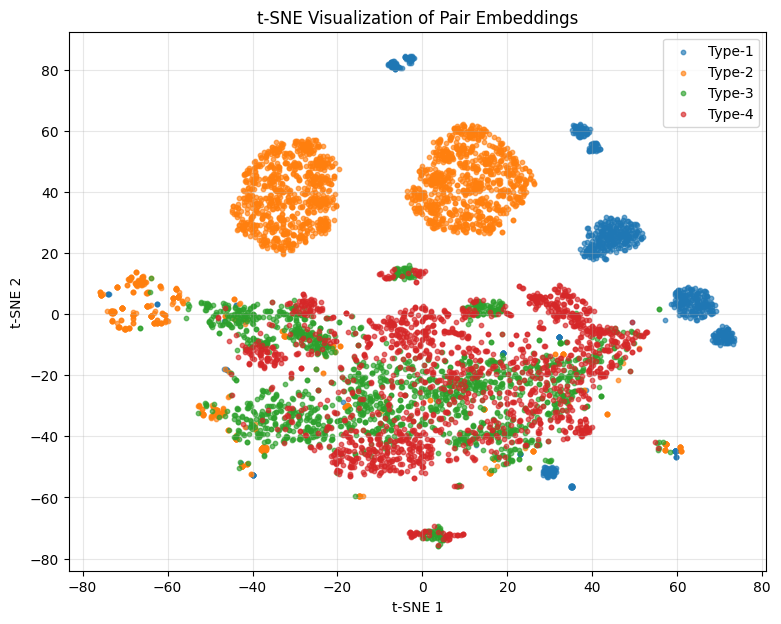

In [32]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne_all_classes(embeddings, labels):
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=42
    )

    emb_2d = tsne.fit_transform(embeddings)

    class_names = ["Type-1", "Type-2", "Type-3", "Type-4"]

    plt.figure(figsize=(9, 7))

    for c in range(4):
        mask = labels == c
        plt.scatter(
            emb_2d[mask, 0],
            emb_2d[mask, 1],
            s=10,
            alpha=0.65,
            label=class_names[c]
        )

    plt.title("t-SNE Visualization of Pair Embeddings")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return emb_2d

emb_2d = plot_tsne_all_classes(embeddings, labels)

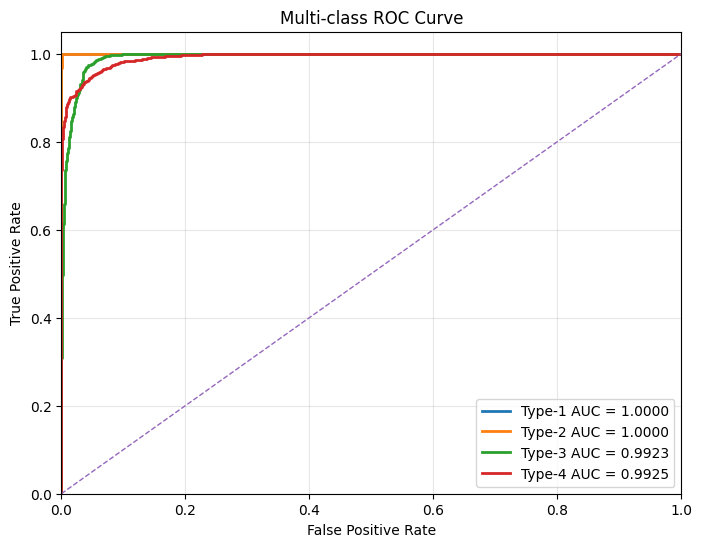

ROC AUC: {0: np.float64(0.9999986995490036), 1: np.float64(0.9999531357047087), 2: np.float64(0.9922769444449472), 3: np.float64(0.9924708358412775)}


In [33]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_multiclass_roc(labels, probs, num_classes=4):
    labels_bin = label_binarize(labels, classes=list(range(num_classes)))

    class_names = ["Type-1", "Type-2", "Type-3", "Type-4"]

    fpr = {}
    tpr = {}
    roc_auc = {}

    plt.figure(figsize=(8, 6))

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(
            fpr[i],
            tpr[i],
            lw=2,
            label=f"{class_names[i]} AUC = {roc_auc[i]:.4f}"
        )

    plt.plot([0, 1], [0, 1], linestyle="--", lw=1)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-class ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

    return roc_auc

roc_auc = plot_multiclass_roc(labels, probs, num_classes=4)
print("ROC AUC:", roc_auc)

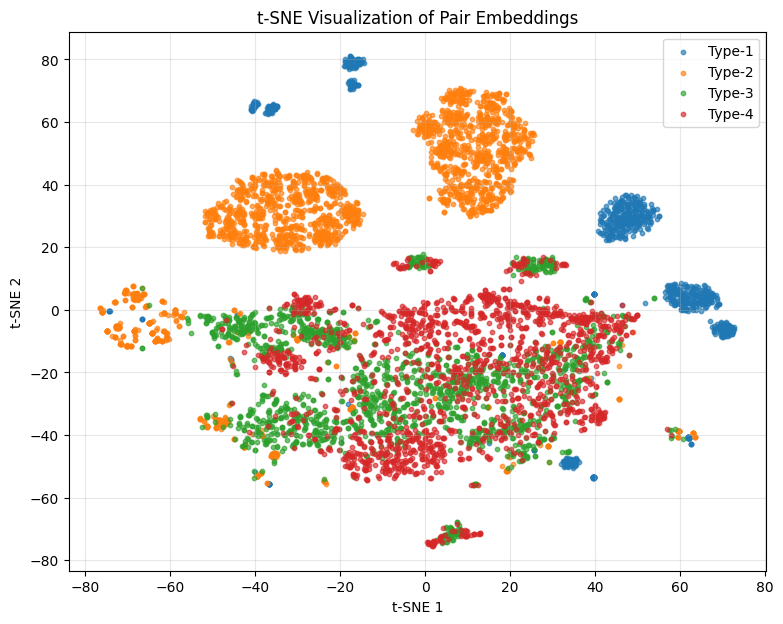

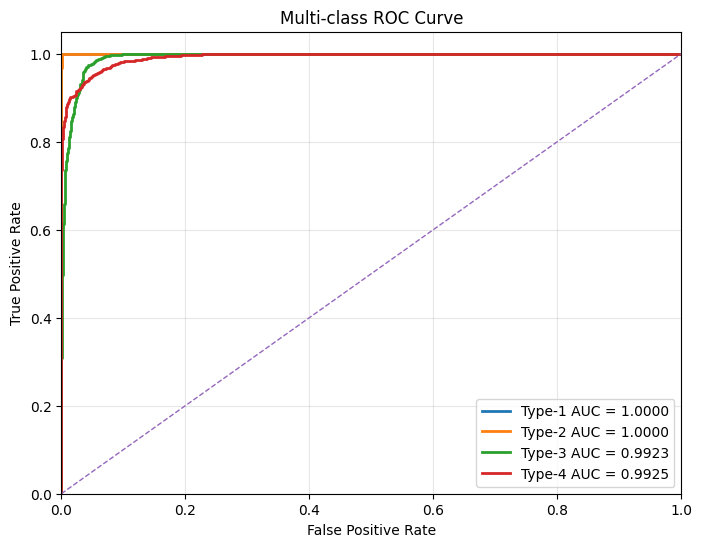

In [34]:
embeddings, probs, preds, labels = collect_outputs_for_tsne_roc(
    pair_model,
    test_loader,
    device
)

emb_2d = plot_tsne_all_classes(embeddings, labels)

# emb_2d_34 = plot_tsne_type34(embeddings, labels)

roc_auc = plot_multiclass_roc(labels, probs, num_classes=4)

# auc_34 = plot_roc_type3_vs_type4(labels, probs)

In [24]:
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

def plot_tsne_all_classes(
    embeddings,
    labels,
    class_names=None,
    save_path="/kaggle/working/tsne_all_classes.png",
    max_samples=3000,
    random_state=42
):
    class_names = class_names or ["Type-1", "Type-2", "Type-3", "Type-4"]

    embeddings = np.asarray(embeddings)
    labels = np.asarray(labels)

    # =========================
    # Lấy tối đa 3000 mẫu
    # =========================
    if embeddings.shape[0] > max_samples:
        all_idx = np.arange(embeddings.shape[0])

        _, sample_idx = train_test_split(
            all_idx,
            test_size=max_samples,
            random_state=random_state,
            stratify=labels
        )

        embeddings = embeddings[sample_idx]
        labels = labels[sample_idx]

    n_samples = embeddings.shape[0]
    perplexity = min(30, max(5, (n_samples - 1) // 3))

    print(f"Running T-SNE with perplexity={perplexity}, n_samples={n_samples}")

    # Chuẩn hóa embedding
    embeddings = StandardScaler().fit_transform(embeddings)

    # Giảm chiều trước bằng PCA cho nhanh hơn
    if embeddings.shape[1] > 50:
        embeddings = PCA(
            n_components=50,
            random_state=random_state
        ).fit_transform(embeddings)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        method="barnes_hut",
        random_state=random_state,
        max_iter=1000,
        verbose=1
    )

    emb_2d = tsne.fit_transform(embeddings)

    # =========================
    # Vẽ hình
    # =========================
    plt.figure(figsize=(10, 8))

    for cls_idx, cls_name in enumerate(class_names):
        mask = labels == cls_idx

        plt.scatter(
            emb_2d[mask, 0],
            emb_2d[mask, 1],
            s=28,
            alpha=0.75,
            label=cls_name
        )

    plt.title("T-SNE Visualization of Pair Embeddings", fontsize=16)
    plt.xlabel("T-SNE Dimension 1", fontsize=13)
    plt.ylabel("T-SNE Dimension 2", fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved T-SNE figure to: {save_path}")

    return emb_2d

In [ ]:
emb_2d = plot_tsne_all_classes(
    embeddings,
    labels,
    class_names=["Type-1", "Type-2", "Type-3", "Type-4"],
    save_path="/kaggle/working/tsne_all_classes.png",
    max_samples=3000
)